In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from minimos_cuadrados import minimos_cuadrados
from minimos_cuadrado_vid import minimos_cuadrados_vid
from spline_cubico_natural_vid import spline_cubico_natural_vid

In [2]:
# Cargar el dataframe con las variables que se van a utilizar
df = pd.read_csv(r"asthma_disease_data.csv")
pd.set_option('display.max_rows', None)
cols = [
    "Age", "Gender", "PollutionExposure", "PollenExposure", "DustExposure",
    "FamilyHistoryAsthma", "Smoking", "PhysicalActivity",
    "DietQuality", "HistoryOfAllergies" , "Diagnosis"
]
# Vuelve a cargar el dataframe con las variables seleccionadas
df = pd.read_csv("asthma_disease_data.csv", usecols=cols)
# Elimina las filas con valores nulos
df = df.dropna()
print(df)

      Age  Gender  Smoking  PhysicalActivity  DietQuality  PollutionExposure  \
0      63       0        0          0.894448     5.488696           7.388481   
1      26       1        0          5.897329     6.341014           1.969838   
2      57       0        0          6.739367     9.196237           1.460593   
3      40       1        0          1.404503     5.826532           0.581905   
4      61       0        0          4.604493     3.127048           0.980875   
5      21       0        0          0.470044     1.759118           1.711446   
6      45       1        1          9.371784     7.030507           7.664306   
7      26       0        1          8.344096     1.626484           6.939046   
8      49       1        0          2.690256     3.920034           3.180421   
9      45       1        0          2.895720     2.607700           1.711722   
10     27       0        0          3.900003     1.748193           1.546419   
11     62       1        0          6.63

In [3]:
# Detección y limpieza de outliers usando el método IQR
numeric_cols = [
    "Age", "PollutionExposure", "PollenExposure", "DustExposure",
    "PhysicalActivity", "DietQuality"
]
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"{col}: Se eliminarán {outliers.shape[0]} outliers")
    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

print('Dimensiones del dataframe después de limpiar outliers:', df.shape)

Age: Se eliminarán 0 outliers
PollutionExposure: Se eliminarán 0 outliers
PollenExposure: Se eliminarán 0 outliers
DustExposure: Se eliminarán 0 outliers
PhysicalActivity: Se eliminarán 0 outliers
DietQuality: Se eliminarán 0 outliers
Dimensiones del dataframe después de limpiar outliers: (2392, 11)


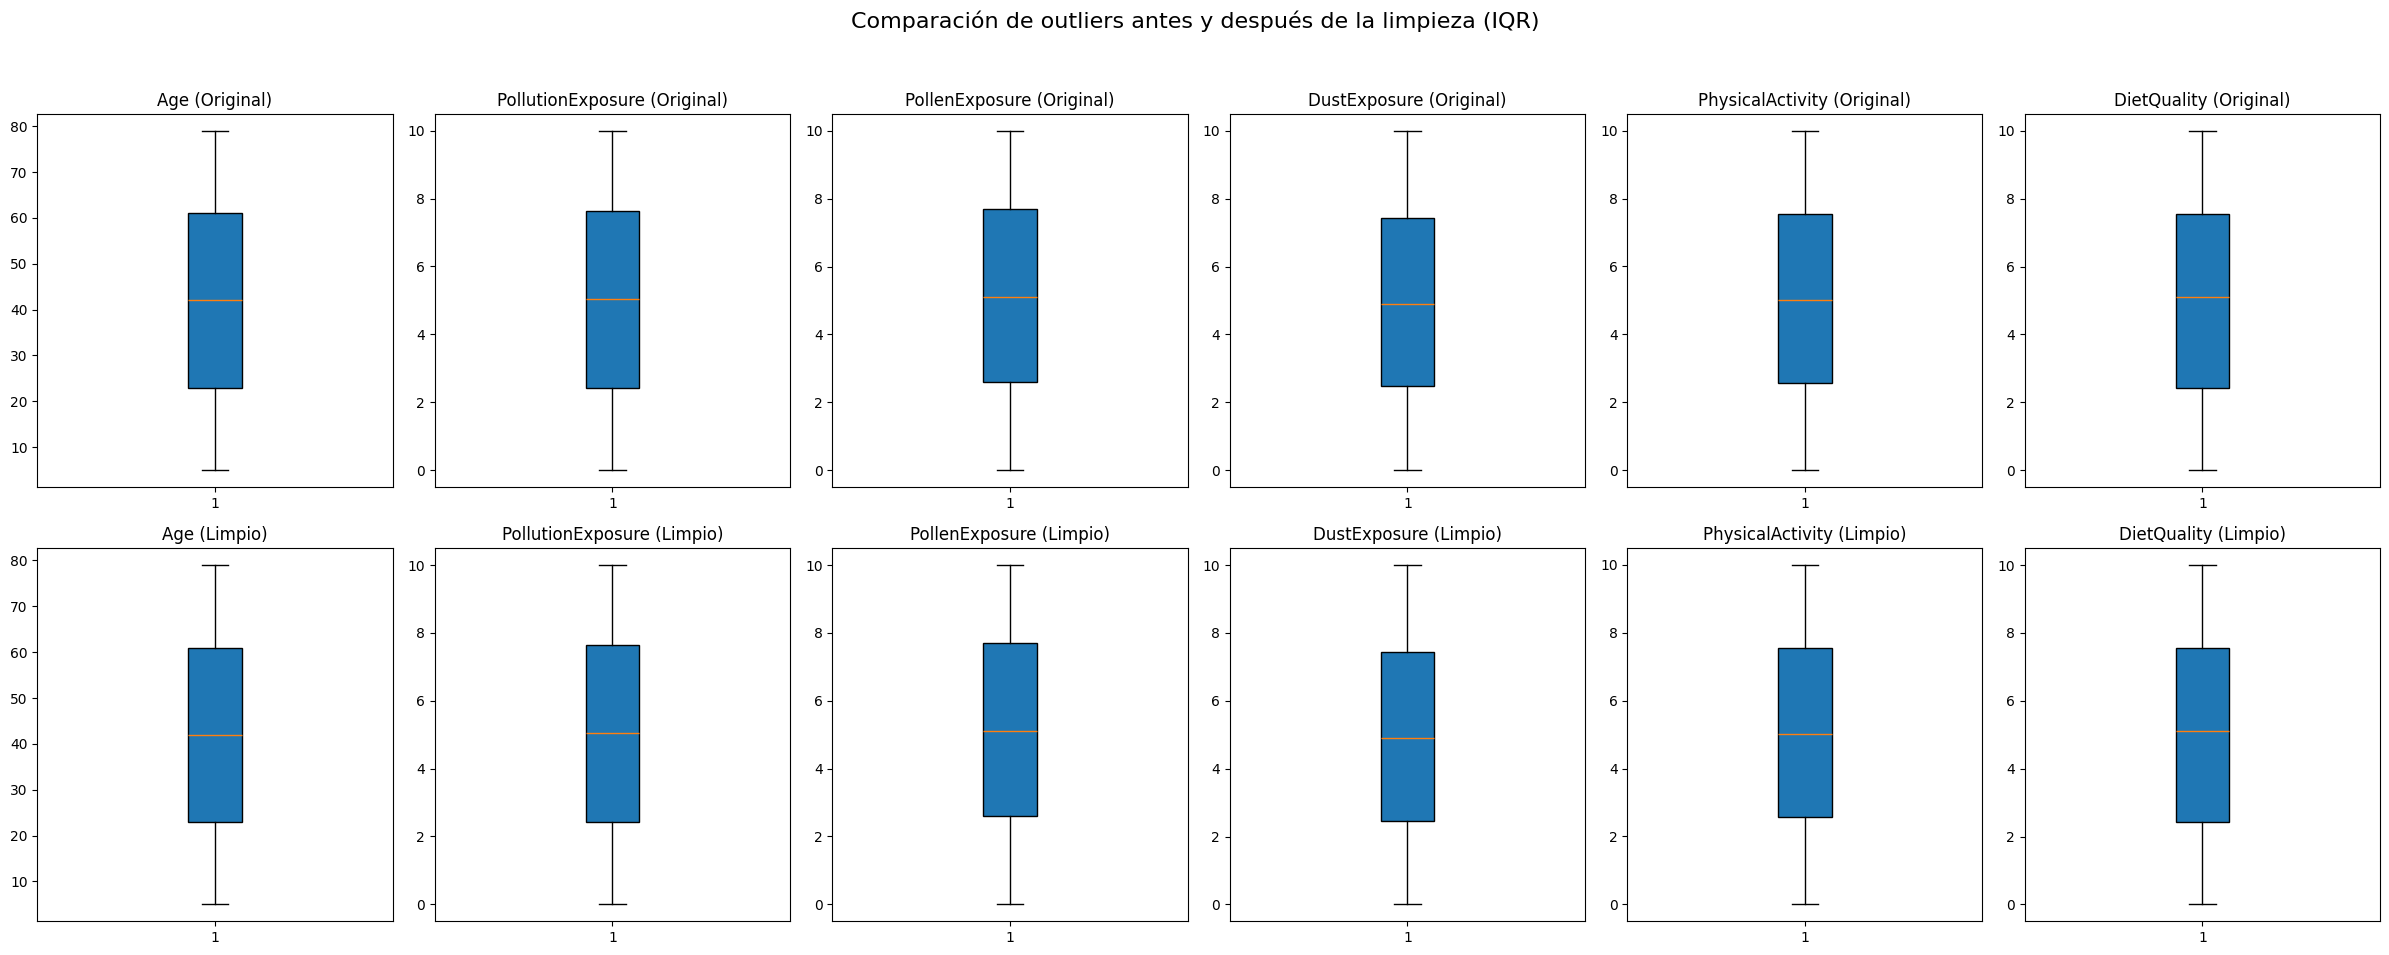

In [4]:
# Visualización de outliers antes y después de la limpieza con boxplots
fig, axes = plt.subplots(2, len(numeric_cols), figsize=(4*len(numeric_cols), 10))
for i, col in enumerate(numeric_cols):
    # Boxplot antes de la limpieza
    original_data = pd.read_csv("asthma_disease_data.csv", usecols=[col]).dropna()
    axes[0, i].boxplot(original_data[col], vert=True, patch_artist=True)
    axes[0, i].set_title(f'{col} (Original)')
    # Boxplot después de la limpieza
    axes[1, i].boxplot(df[col], vert=True, patch_artist=True)
    axes[1, i].set_title(f'{col} (Limpio)')
plt.suptitle('Comparación de outliers antes y después de la limpieza (IQR)', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [5]:
# Muestra las dimensiones del dataframe
df.shape

(2392, 11)

In [6]:
# Muestra la información detallada del dataframe para verificar los tipos de datos y si existen valores nulos.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2392 entries, 0 to 2391
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  2392 non-null   int64  
 1   Gender               2392 non-null   int64  
 2   Smoking              2392 non-null   int64  
 3   PhysicalActivity     2392 non-null   float64
 4   DietQuality          2392 non-null   float64
 5   PollutionExposure    2392 non-null   float64
 6   PollenExposure       2392 non-null   float64
 7   DustExposure         2392 non-null   float64
 8   FamilyHistoryAsthma  2392 non-null   int64  
 9   HistoryOfAllergies   2392 non-null   int64  
 10  Diagnosis            2392 non-null   int64  
dtypes: float64(5), int64(6)
memory usage: 205.7 KB


<Figure size 1000x600 with 0 Axes>

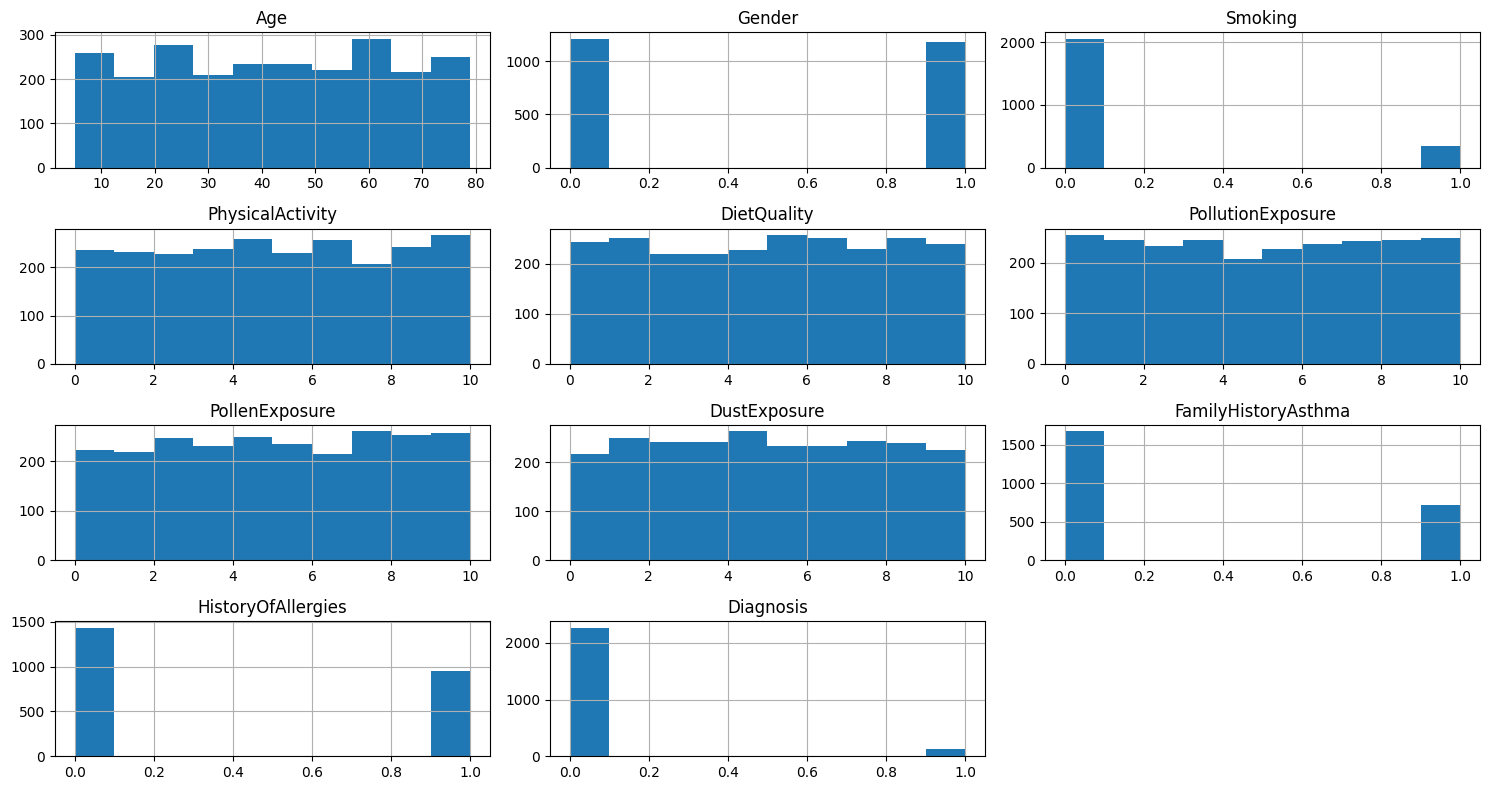

In [7]:
# Visualización de la distribución de los datos
plt.figure(figsize=(10, 6))
df.describe()
df.hist(figsize=(15, 8))
plt.tight_layout()
plt.show()

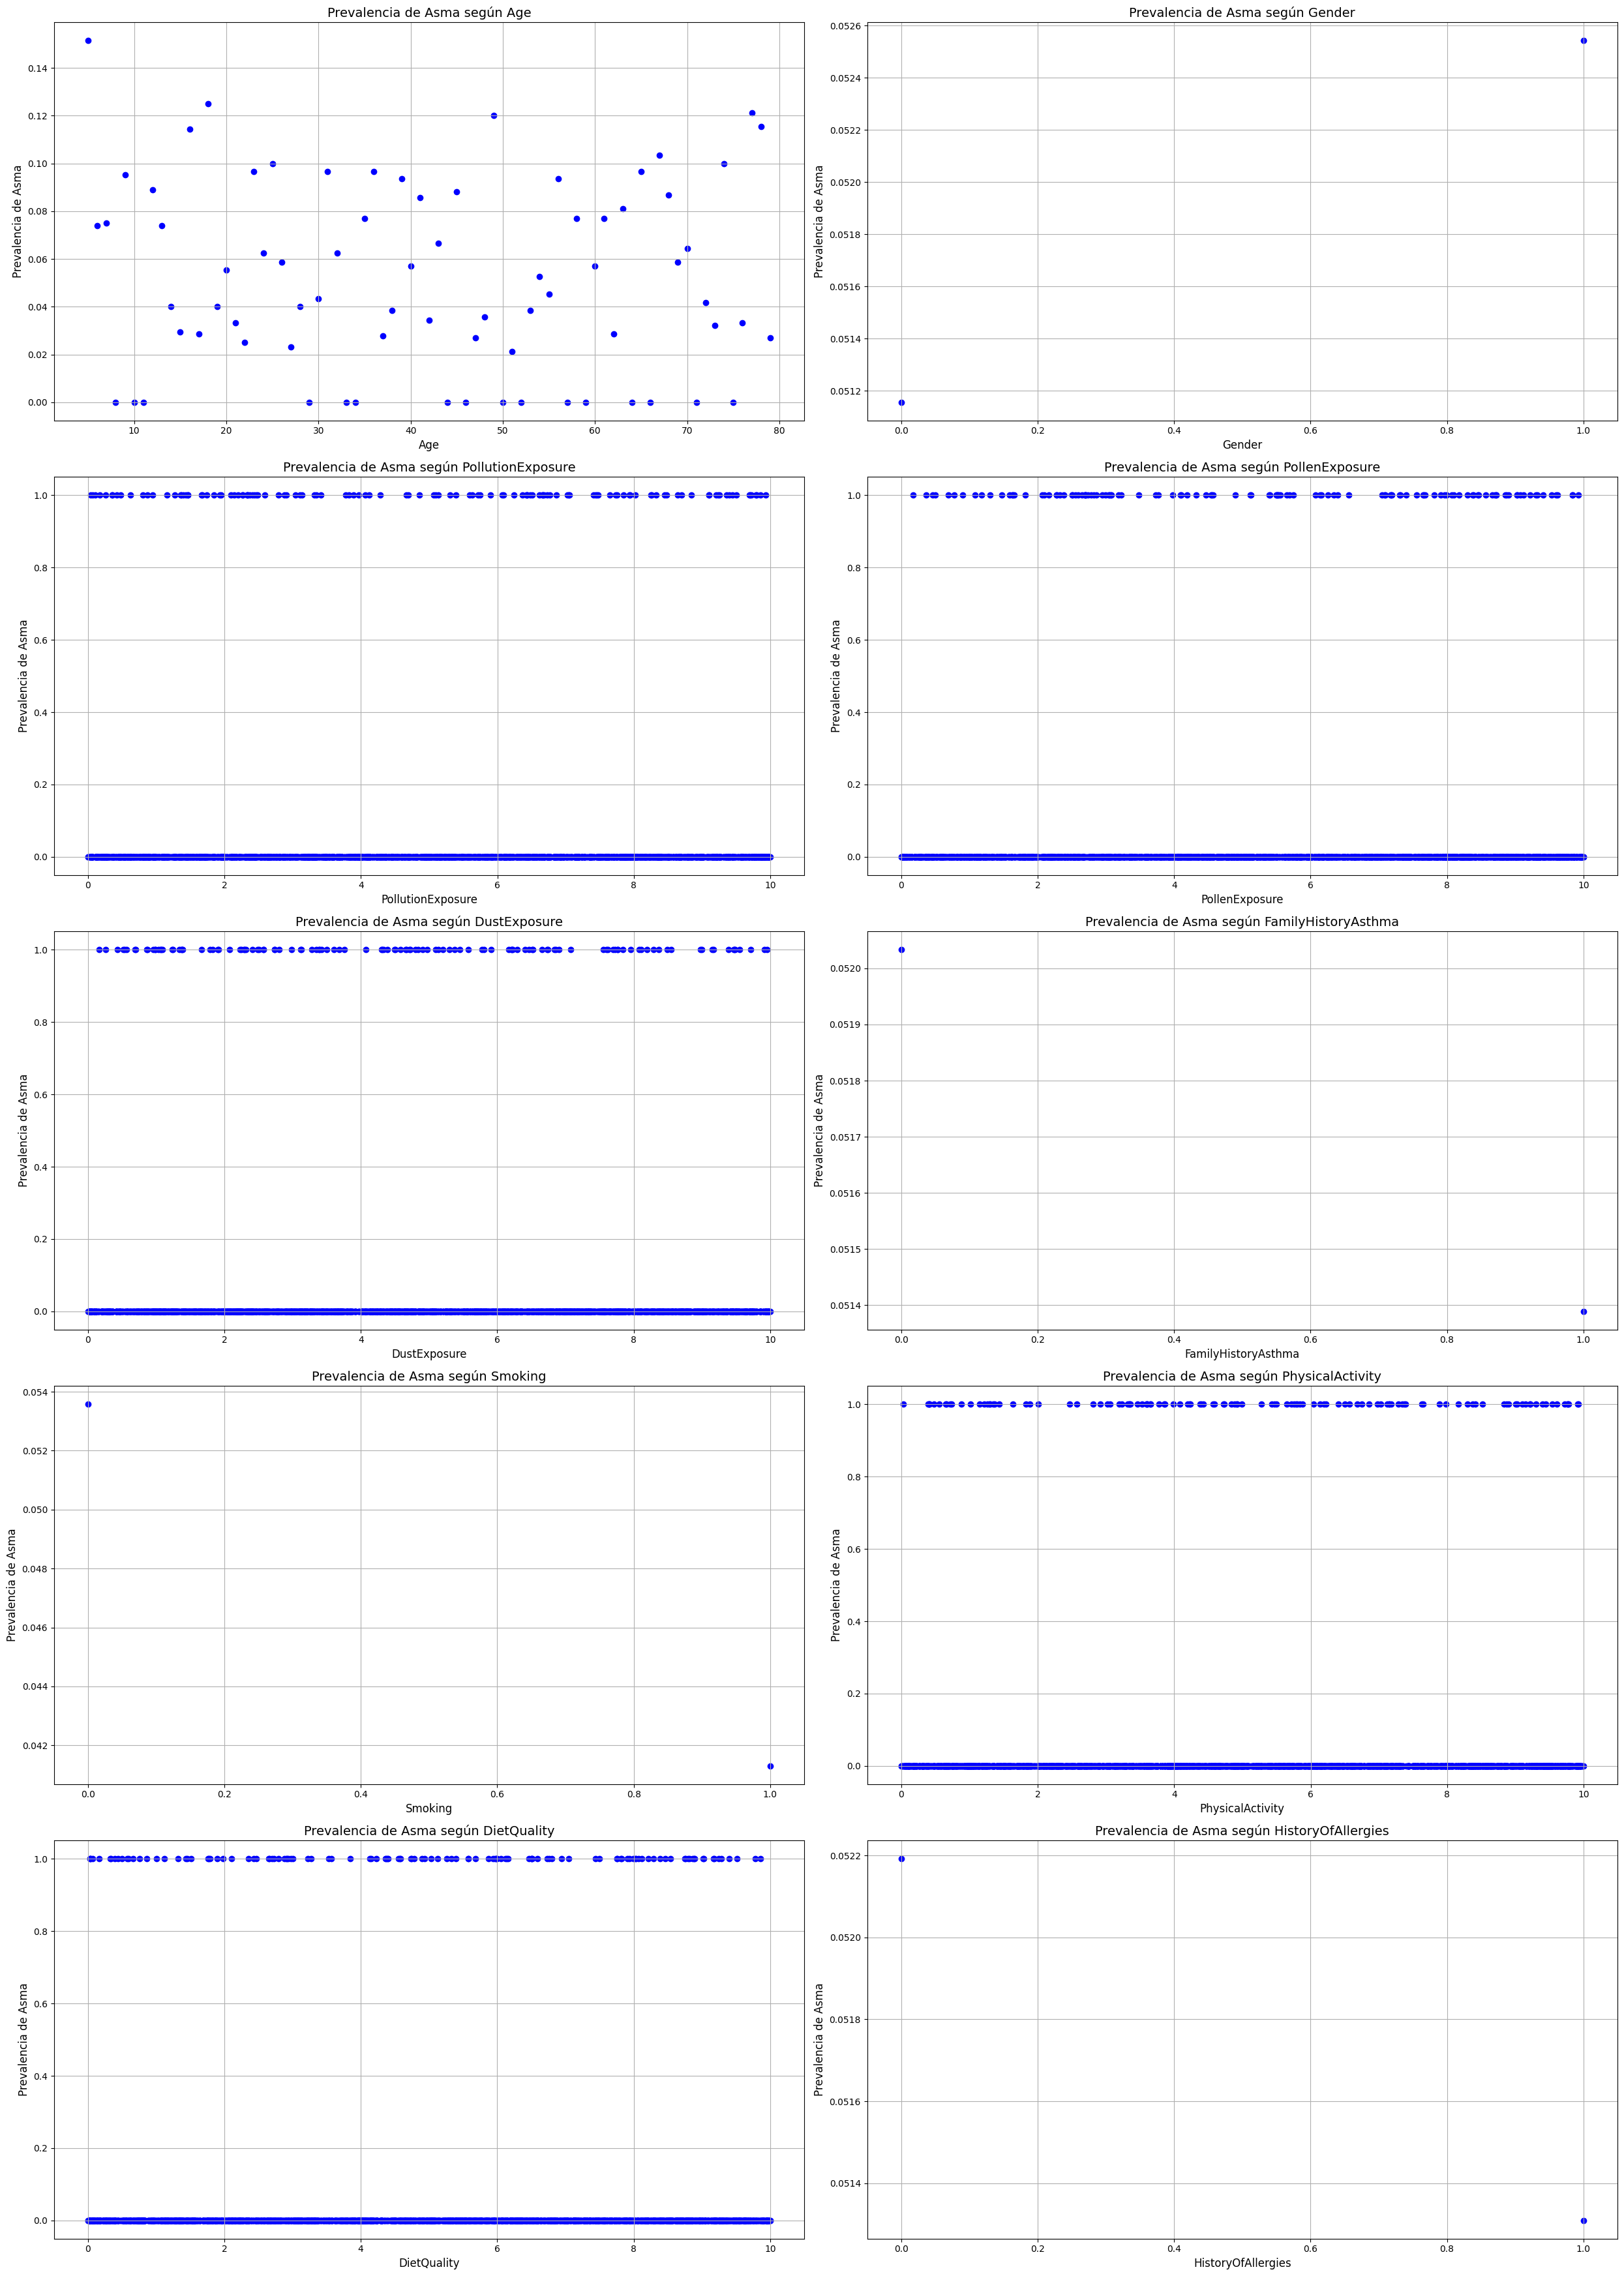

In [8]:
#Gráfica de Prevalencia del Asma (Diagnosis) vs Variables
df = df[cols].dropna()

# Variables independientes para analizar
variables = [
    "Age", "Gender", "PollutionExposure", "PollenExposure", "DustExposure",
    "FamilyHistoryAsthma", "Smoking", "PhysicalActivity",
    "DietQuality", "HistoryOfAllergies"
]

fig, axes = plt.subplots(5, 2, figsize=(25, 35))
axes = axes.flatten()

# Generación de gráficas individuales para cada relación
for i, var in enumerate(variables):
    prevalencia = df.groupby(var)['Diagnosis'].mean()
    x = prevalencia.index
    y = prevalencia.values

    axes[i].scatter(x, y, color='blue')
    axes[i].set_title(f'Prevalencia de Asma según {var}', fontsize=14)
    axes[i].set_xlabel(var, fontsize=12)
    axes[i].set_ylabel('Prevalencia de Asma', fontsize=12)
    axes[i].grid(True)

plt.tight_layout()
plt.show()

Text(0.5, 0, 'Grupo de Edad')

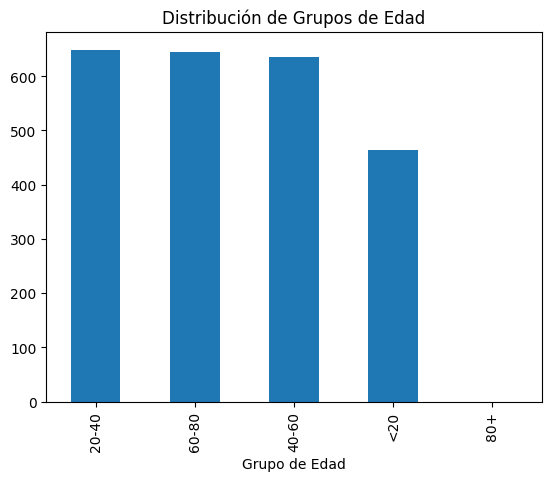

In [9]:
# Agrupación de edades en grupos
max_edad = max(80, df['Age'].max()) + 1
rangos = [0, 20, 40, 60, 80, max_edad]
labels = ['<20', '20‑40', '40‑60', '60‑80', '80+']
df['AgeGroup'] = pd.cut(df['Age'], bins=rangos, labels=labels, right=False)
df['AgeGroup'].value_counts().plot(kind='bar', title='Distribución de Grupos de Edad')
plt.xlabel('Grupo de Edad')

/tmp/ipykernel_3933/1708734768.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  prevalencia = df.groupby(var)['Diagnosis'].mean()


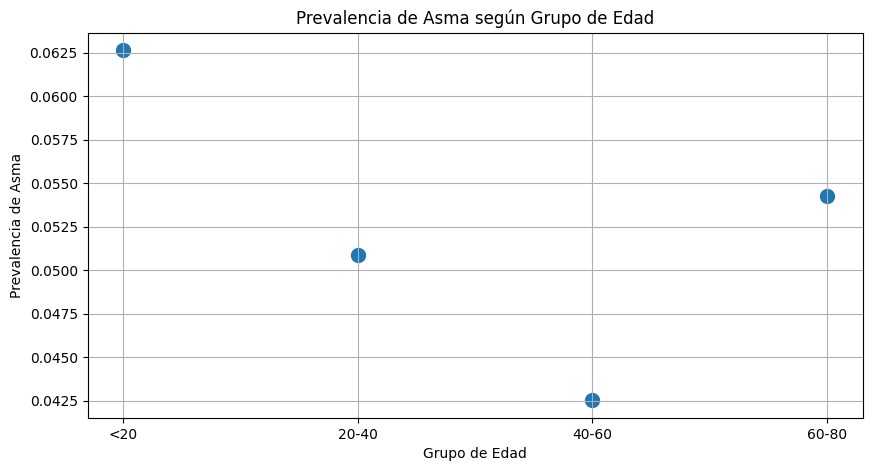

/tmp/ipykernel_3933/1708734768.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  prevalencia = df.groupby(var)['Diagnosis'].mean()


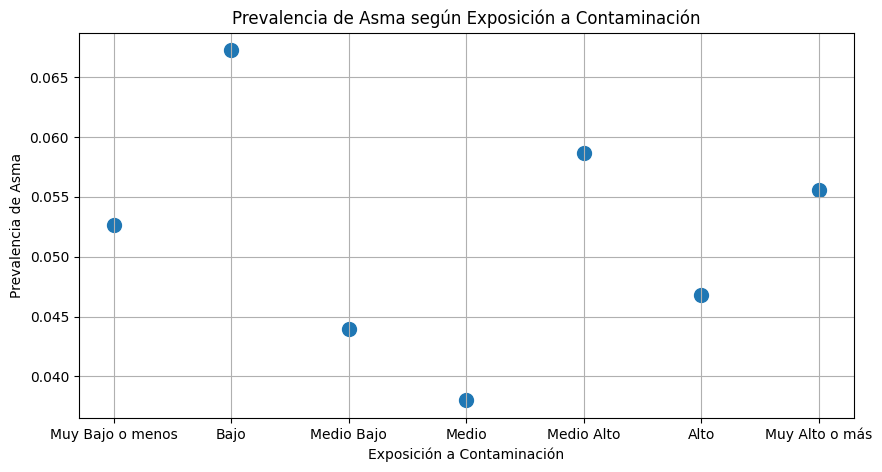

/tmp/ipykernel_3933/1708734768.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  prevalencia = df.groupby(var)['Diagnosis'].mean()


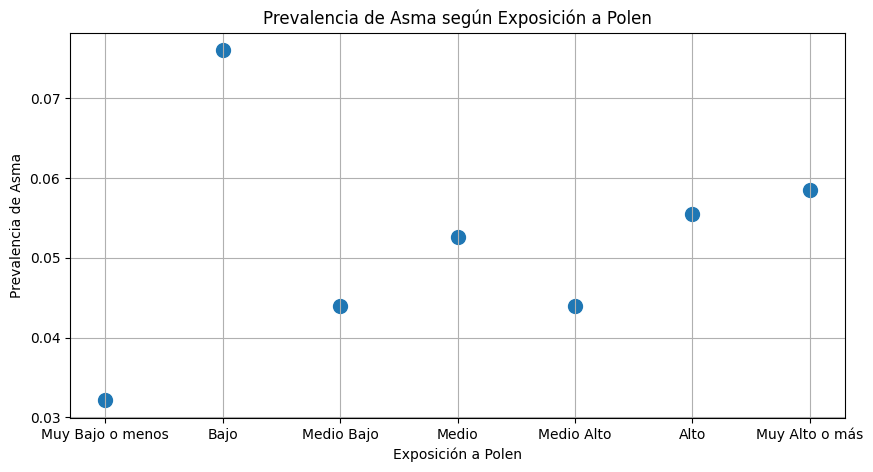

/tmp/ipykernel_3933/1708734768.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  prevalencia = df.groupby(var)['Diagnosis'].mean()


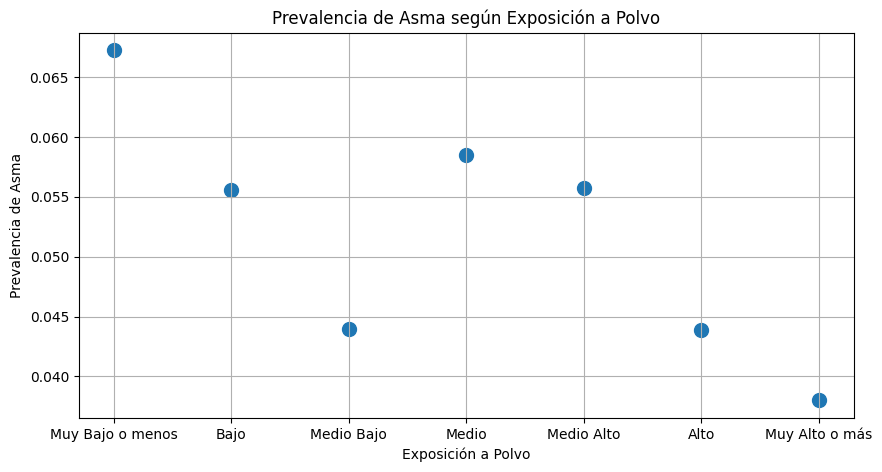

/tmp/ipykernel_3933/1708734768.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  prevalencia = df.groupby(var)['Diagnosis'].mean()


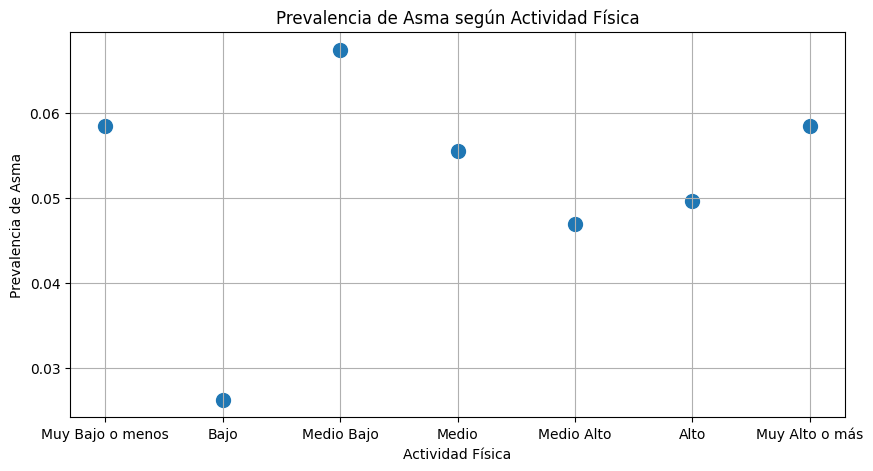

/tmp/ipykernel_3933/1708734768.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  prevalencia = df.groupby(var)['Diagnosis'].mean()


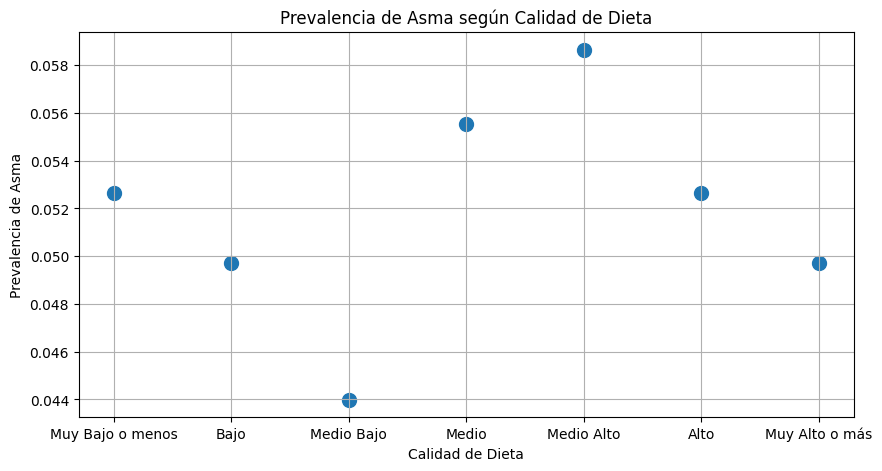

In [10]:
#Etiquetas para la distribucion en grupos en las demas variables.
etiquetas = ['Muy Bajo o menos', 'Bajo', 'Medio Bajo', 'Medio', 'Medio Alto', 'Alto', 'Muy Alto o más']

for var in ['PollutionExposure', 'PollenExposure', 'DustExposure', 'PhysicalActivity', 'DietQuality']:
    try:
        df[var + 'Group'] = pd.qcut(df[var], q=7, labels=etiquetas, duplicates='drop')
    except ValueError:
        df[var + 'Group'] = pd.cut(df[var], bins=7, labels=etiquetas, include_lowest=True)

agrupadas = {
    'AgeGroup': 'Grupo de Edad',
    'PollutionExposureGroup': 'Exposición a Contaminación',
    'PollenExposureGroup': 'Exposición a Polen',
    'DustExposureGroup': 'Exposición a Polvo',
    'PhysicalActivityGroup': 'Actividad Física',
    'DietQualityGroup': 'Calidad de Dieta'
}

#Visualización de Prevalencia de Asma vs variables en grupos (de ser necesario)
for var, titulo in agrupadas.items():
    prevalencia = df.groupby(var)['Diagnosis'].mean()
    plt.figure(figsize=(10,5))
    plt.scatter(prevalencia.index.astype(str), prevalencia.values, s=100)
    plt.title(f'Prevalencia de Asma según {titulo}')
    plt.xlabel(titulo)
    plt.ylabel('Prevalencia de Asma')
    plt.grid(True)
    plt.show()

In [11]:
# Ver los límites (mínimos, máximos) y cantidad de datos en cada grupo para todas las variables agrupadas. 
for var in agrupadas:
    print(f"\n{'-'*100}\nDistribución de grupos para: {var}")
    # Muestra las etiquetas y los cortes usados por pandas
    for label in df[var].cat.categories:
        valores = df.loc[df[var] == label, var.replace('Group', '')]
        print(f"{label}: {valores.min()} a {valores.max()} (N={valores.count()})")


----------------------------------------------------------------------------------------------------
Distribución de grupos para: AgeGroup
<20: 5 a 19 (N=463)
20‑40: 20 a 39 (N=649)
40‑60: 40 a 59 (N=635)
60‑80: 60 a 79 (N=645)
80+: nan a nan (N=0)

----------------------------------------------------------------------------------------------------
Distribución de grupos para: PollutionExposureGroup
Muy Bajo o menos: 0.0010215049107153 a 1.397764480679351 (N=342)
Bajo: 1.3984915589261826 a 2.77618270746036 (N=342)
Medio Bajo: 2.78913171216884 a 4.224030177517512 (N=341)
Medio: 4.224505799731445 a 5.782557722587409 (N=342)
Medio Alto: 5.782724380118961 a 7.271006256389818 (N=341)
Alto: 7.271013351994197 a 8.614211318542397 (N=342)
Muy Alto o más: 8.61497773419407 a 9.998964331499586 (N=342)

----------------------------------------------------------------------------------------------------
Distribución de grupos para: PollenExposureGroup
Muy Bajo o menos: 0.0006590280421692 a 1.514786

<center><h2>Selección del método tras las la visualización de las gráficas de prevalencia vs variables independientes<h2></center>

| **Variable**                      | **Método seleccionado** | **Explicación**                                                                               |
| --------------------------------- | ----------------------- | --------------------------------------------------------------------------------------------- |
| **Edad** *(AgeGroup)*             | **Splines cúbicos**     | Relación no lineal entre grupos, con posibles picos en ciertos rangos.                        |
| **Género**                        | **Mínimos cuadrados**   | Sólo hay dos categorías, femenino o masculino.                                                |
| **Contaminación** *(agrupada)*    | **Splines cúbicos**     | La relación no es lineal ni monótona en las 7 etiquetas.                                      |
| **Exposición Pólen** *(agrupada)* | **Mínimos cuadrados**   | Las fluctuaciones son suaves, lo que permite una aproximación lineal.                         |
| **Exposición Polvo** *(agrupada)* | **Mínimos cuadrados**   | Se observa una relación visualmente lineal entre los grupos.                                  |
| **Historia Familiar**             | **Mínimos cuadrados**   | Dos categorías (sí/no), con una comparación directa.                                          |
| **Tabaquismo**                    | **Mínimos cuadrados**   | Dos categorías (sí/no), de forma lineal.                                                      |
| **Actividad Física** *(agrupada)* | **Mínimos cuadrados**   | La relación es ordenada y carece de grandes curvas, lo que permite un ajuste lineal adecuado. |
| **Calidad Dieta** *(agrupada)*    | **Splines cúbicos**     | Se presentan cambios no lineales en los grupos intermedios.                                   |
| **Historial Alergias**            | **Mínimos cuadrados**   | Dos categorías, con un ajuste directo y sencillo.                                             |


/tmp/ipykernel_3933/1862062913.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  prevalencia = df.groupby('AgeGroup')['Diagnosis'].mean()


Variable: Edad

Prevalencia por grupo/categoría:
<20                  0.062635
20‑40                0.050847
40‑60                0.042520
60‑80                0.054264
80+                  nan

Spline cúbico global sobre los valores medios de cada grupo:
Splines cúbicos naturales:
S_0(x) = 0.0706283779697624 - 0.000674*x
S_1(x) = 1.0e-6*x**3 - 8.81741140215716e-5*x**2 + 0.00192255812782971*x + 0.0451200116649452
S_2(x) = -1.0e-6*x**3 + 0.000186979527559055*x**2 - 0.0110684479087358*x + 0.2535333104287


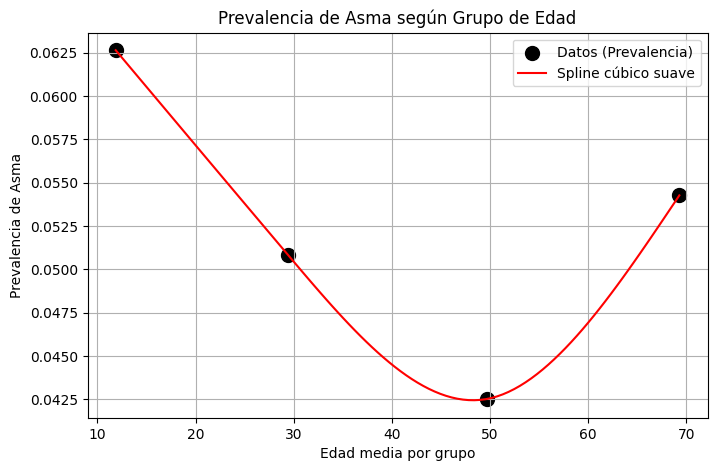

In [12]:
print('Variable: Edad')
if 'AgeGroup' in df.columns:
    print('\nPrevalencia por grupo/categoría:')
    prevalencia = df.groupby('AgeGroup')['Diagnosis'].mean()
    for label, prev in prevalencia.items():
        print(f'{label:20} {prev:.6f}')
    x_medios = [df.loc[df['AgeGroup'] == label, 'Age'].mean() for label in df['AgeGroup'].cat.categories]
    y_prevalencia = [prevalencia[label] for label in df['AgeGroup'].cat.categories]
    # Elimina nan de ambos arreglos
    x_filtradoE = []
    y_filtradoE = []
    for x, y in zip(x_medios, y_prevalencia):
        if not (pd.isna(x) or pd.isna(y)):
            x_filtradoE.append(x)
            y_filtradoE.append(y)
    print('\nSpline cúbico global sobre los valores medios de cada grupo:')
    if len(x_filtradoE) > 1:
        spline = spline_cubico_natural_vid(x_filtradoE, y_filtradoE, 6)
        if spline and 'evaluar' in spline:
            x_spline = np.linspace(min(x_filtradoE), max(x_filtradoE), 100)
            y_spline = spline['evaluar'](x_spline)
            import matplotlib.pyplot as plt
            plt.figure(figsize=(8,5))
            plt.scatter(x_filtradoE, y_filtradoE, color='black', s=100, label='Datos (Prevalencia)')
            plt.plot(x_spline, y_spline, color='red', label='Spline cúbico suave')
            plt.title('Prevalencia de Asma según Grupo de Edad')
            plt.xlabel('Edad media por grupo')
            plt.ylabel('Prevalencia de Asma')
            plt.legend()
            plt.grid(True)
            plt.show()
        else:
            print('No se pudo calcular el spline.')
    else:
        print('No hay suficientes datos válidos para graficar el spline.')

Variable: Género

Prevalencia por grupo/categoría:
                   0 0.051155
                   1 0.052542

Ajuste mínimos cuadrados:
0.001387, 0.051155
Ajuste: y = 0.001387 * x + 0.051155


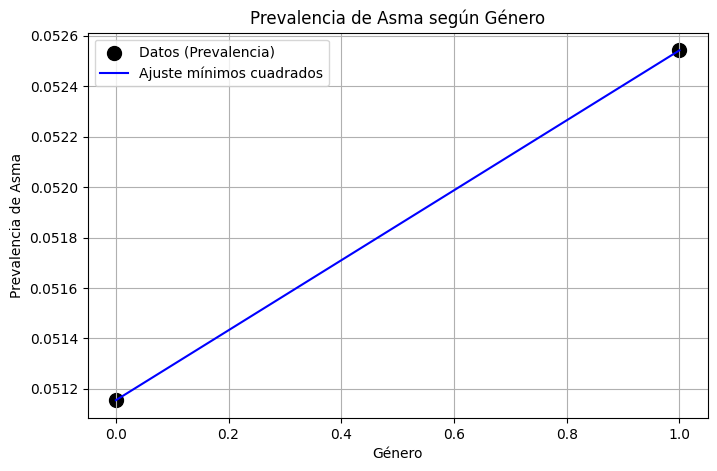

In [13]:
print('Variable: Género')
if 'Gender' in df.columns:
    print('\nPrevalencia por grupo/categoría:')
    prevalencia = df.groupby('Gender')['Diagnosis'].mean()
    for label, prev in prevalencia.items():
        print(f'{label:20} {prev:.6f}')
    x = list(prevalencia.index)
    y = list(prevalencia.values)
    print('\nAjuste mínimos cuadrados:')
    resultado = minimos_cuadrados(x, y, 6)
    print(', '.join(f'{float(r):.6f}' for r in resultado))
    # Mostrar ecuación explícita
    if len(resultado) >= 2:
        print(f'Ajuste: y = {resultado[0]:.6f} * x + {resultado[1]:.6f}')
    # Graficar ajuste
    import matplotlib.pyplot as plt
    plt.figure(figsize=(8,5))
    plt.scatter(x, y, color='black', s=100, label='Datos (Prevalencia)')
    y_fit = [resultado[0]*xi + resultado[1] for xi in x]
    plt.plot(x, y_fit, color='blue', label='Ajuste mínimos cuadrados')
    plt.title('Prevalencia de Asma según Género')
    plt.xlabel('Género')
    plt.ylabel('Prevalencia de Asma')
    plt.legend()
    plt.grid(True)
    plt.show()

Variable: Exposición a Contaminación

Prevalencia por grupo/categoría:
Muy Bajo o menos     0.052632
Bajo                 0.067251
Medio Bajo           0.043988
Medio                0.038012
Medio Alto           0.058651
Alto                 0.046784
Muy Alto o más       0.055556

Spline cúbico global sobre los valores medios de cada grupo:
Splines cúbicos naturales:
S_0(x) = -0.00396*x**3 + 0.00831387685865342*x**2 + 0.0123307720184467*x + 0.0412881834357773
S_1(x) = 0.005678*x**3 - 0.0519400903988594*x**2 + 0.137893272375348*x - 0.0459315095746991
S_2(x) = 0.000772*x**3 - 0.00052644065515264*x**2 - 0.0417761779950788*x + 0.163438863390133
S_3(x) = -0.006208*x**3 + 0.104391649531525*x**2 - 0.567446883586375*x + 1.0413409474087
S_4(x) = 0.006752*x**3 - 0.148938441664747*x**2 + 1.08306087349542*x - 2.5429013611261
S_5(x) = -0.002864*x**3 + 0.0802733990891548*x**2 - 0.738106346988678*x + 2.2802730214404


/tmp/ipykernel_3933/2498813487.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  prevalencia = df.groupby('PollutionExposureGroup')['Diagnosis'].mean()


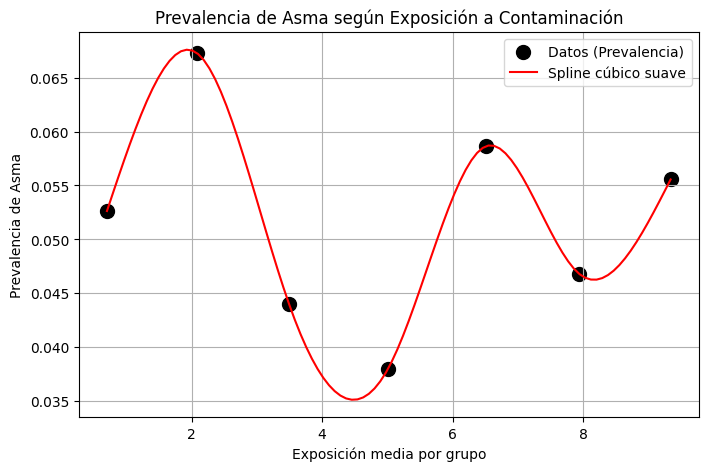

In [14]:
print('Variable: Exposición a Contaminación')
if 'PollutionExposureGroup' in df.columns:
    print('\nPrevalencia por grupo/categoría:')
    prevalencia = df.groupby('PollutionExposureGroup')['Diagnosis'].mean()
    for label, prev in prevalencia.items():
        print(f'{label:20} {prev:.6f}')
    x_medios = [df.loc[df['PollutionExposureGroup'] == label, 'PollutionExposure'].mean() for label in df['PollutionExposureGroup'].cat.categories]
    y_prevalencia = [prevalencia[label] for label in df['PollutionExposureGroup'].cat.categories]
    x_filtrado = []
    y_filtrado = []
    for x, y in zip(x_medios, y_prevalencia):
        if not (pd.isna(x) or pd.isna(y)):
            x_filtrado.append(x)
            y_filtrado.append(y)
    print('\nSpline cúbico global sobre los valores medios de cada grupo:')
    if len(x_filtrado) > 1:
        spline = spline_cubico_natural_vid(x_filtrado, y_filtrado, 6)
        if spline and 'evaluar' in spline:
            x_spline = np.linspace(min(x_filtrado), max(x_filtrado), 100)
            y_spline = spline['evaluar'](x_spline)
            import matplotlib.pyplot as plt
            plt.figure(figsize=(8,5))
            plt.scatter(x_filtrado, y_filtrado, color='black', s=100, label='Datos (Prevalencia)')
            plt.plot(x_spline, y_spline, color='red', label='Spline cúbico suave')
            plt.title('Prevalencia de Asma según Exposición a Contaminación')
            plt.xlabel('Exposición media por grupo')
            plt.ylabel('Prevalencia de Asma')
            plt.legend()
            plt.grid(True)
            plt.show()
        else:
            print('No se pudo calcular el spline.')
    else:
        print('No hay suficientes datos válidos para graficar el spline.')

Variable: Exposición a Polvo

Prevalencia por grupo/categoría:
Muy Bajo o menos     0.067251
Bajo                 0.055556
Medio Bajo           0.043988
Medio                0.058480
Medio Alto           0.055718
Alto                 0.043860
Muy Alto o más       0.038012

Ajuste mínimos cuadrados:
-0.002511, 0.064346
Ajuste: y = -0.002511 * x + 0.064346


/tmp/ipykernel_3933/3214248396.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  prevalencia = df.groupby('DustExposureGroup')['Diagnosis'].mean()


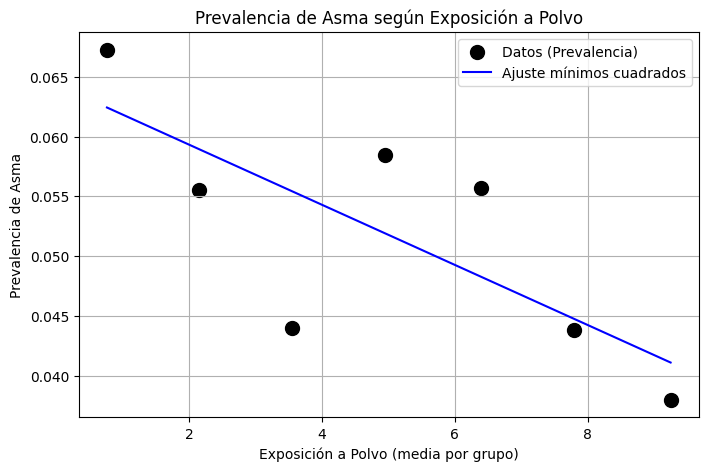

In [15]:
print('Variable: Exposición a Polvo')
if 'DustExposureGroup' in df.columns:
    print('\nPrevalencia por grupo/categoría:')
    prevalencia = df.groupby('DustExposureGroup')['Diagnosis'].mean()
    for label, prev in prevalencia.items():
        print(f'{label:20} {prev:.6f}')
    x_medios = [df.loc[df['DustExposureGroup'] == label, 'DustExposure'].mean() for label in df['DustExposureGroup'].cat.categories]
    y_prevalencia = [prevalencia[label] for label in df['DustExposureGroup'].cat.categories]
    print('\nAjuste mínimos cuadrados:')
    resultado = minimos_cuadrados(x_medios, y_prevalencia, 6)
    print(', '.join(f'{float(r):.6f}' for r in resultado))
    if len(resultado) >= 2:
        print(f'Ajuste: y = {resultado[0]:.6f} * x + {resultado[1]:.6f}')
    # Graficar ajuste
    import matplotlib.pyplot as plt
    plt.figure(figsize=(8,5))
    plt.scatter(x_medios, y_prevalencia, color='black', s=100, label='Datos (Prevalencia)')
    y_fit = [resultado[0]*xi + resultado[1] for xi in x_medios]
    plt.plot(x_medios, y_fit, color='blue', label='Ajuste mínimos cuadrados')
    plt.title('Prevalencia de Asma según Exposición a Polvo')
    plt.xlabel('Exposición a Polvo (media por grupo)')
    plt.ylabel('Prevalencia de Asma')
    plt.legend()
    plt.grid(True)
    plt.show()

Variable: Exposición a Polen

Prevalencia por grupo/categoría:
Muy Bajo o menos     0.032164
Bajo                 0.076023
Medio Bajo           0.043988
Medio                0.052632
Medio Alto           0.043988
Alto                 0.055556
Muy Alto o más       0.058480

Ajuste mínimos cuadrados:
0.000963, 0.046907
Ajuste: y = 0.000963 * x + 0.046907


/tmp/ipykernel_3933/3878212641.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  prevalencia = df.groupby('PollenExposureGroup')['Diagnosis'].mean()


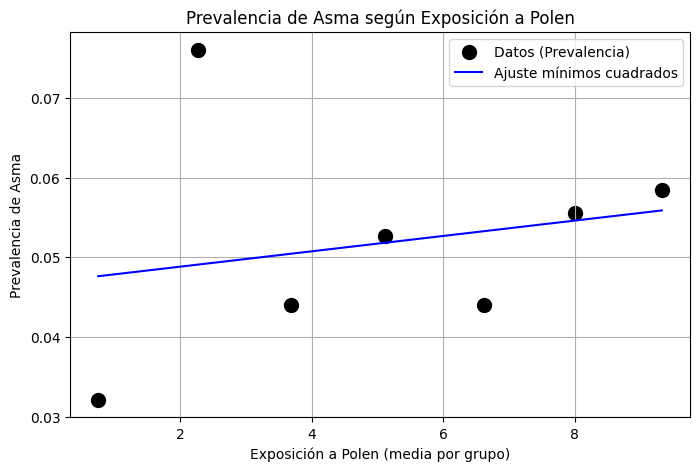

In [16]:
print('Variable: Exposición a Polen')
if 'PollenExposureGroup' in df.columns:
    print('\nPrevalencia por grupo/categoría:')
    prevalencia = df.groupby('PollenExposureGroup')['Diagnosis'].mean()
    for label, prev in prevalencia.items():
        print(f'{label:20} {prev:.6f}')
    x_medios = [df.loc[df['PollenExposureGroup'] == label, 'PollenExposure'].mean() for label in df['PollenExposureGroup'].cat.categories]
    y_prevalencia = [prevalencia[label] for label in df['PollenExposureGroup'].cat.categories]
    print('\nAjuste mínimos cuadrados:')
    resultado = minimos_cuadrados(x_medios, y_prevalencia, 6)
    print(', '.join(f'{float(r):.6f}' for r in resultado))
    if len(resultado) >= 2:
        print(f'Ajuste: y = {resultado[0]:.6f} * x + {resultado[1]:.6f}')
    # Graficar ajuste
    import matplotlib.pyplot as plt
    plt.figure(figsize=(8,5))
    plt.scatter(x_medios, y_prevalencia, color='black', s=100, label='Datos (Prevalencia)')
    y_fit = [resultado[0]*xi + resultado[1] for xi in x_medios]
    plt.plot(x_medios, y_fit, color='blue', label='Ajuste mínimos cuadrados')
    plt.title('Prevalencia de Asma según Exposición a Polen')
    plt.xlabel('Exposición a Polen (media por grupo)')
    plt.ylabel('Prevalencia de Asma')
    plt.legend()
    plt.grid(True)
    plt.show()

Variable: Historia Familiar

Prevalencia por grupo/categoría:
                   0 0.052033
                   1 0.051389

Ajuste mínimos cuadrados:
-0.000645, 0.052033
Ajuste: y = -0.000645 * x + 0.052033


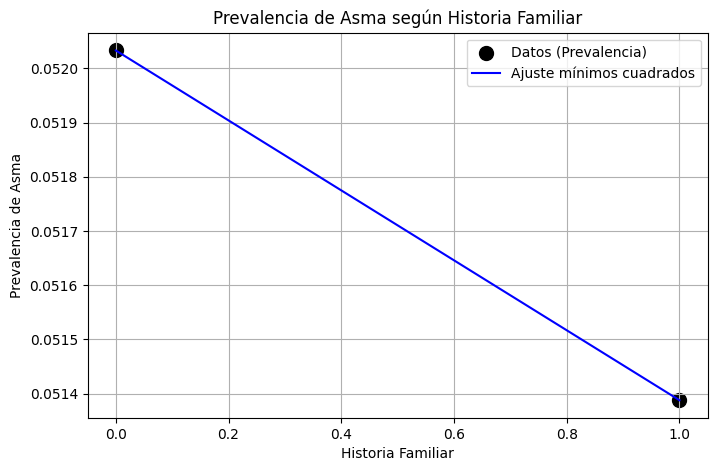

In [17]:
print('Variable: Historia Familiar')
if 'FamilyHistoryAsthma' in df.columns:
    print('\nPrevalencia por grupo/categoría:')
    prevalencia = df.groupby('FamilyHistoryAsthma')['Diagnosis'].mean()
    for label, prev in prevalencia.items():
        print(f'{label:20} {prev:.6f}')
    x = list(prevalencia.index)
    y = list(prevalencia.values)
    print('\nAjuste mínimos cuadrados:')
    resultado = minimos_cuadrados(x, y, 6)
    print(', '.join(f'{float(r):.6f}' for r in resultado))
    if len(resultado) >= 2:
        print(f'Ajuste: y = {resultado[0]:.6f} * x + {resultado[1]:.6f}')
    # Graficar ajuste
    import matplotlib.pyplot as plt
    plt.figure(figsize=(8,5))
    plt.scatter(x, y, color='black', s=100, label='Datos (Prevalencia)')
    y_fit = [resultado[0]*xi + resultado[1] for xi in x]
    plt.plot(x, y_fit, color='blue', label='Ajuste mínimos cuadrados')
    plt.title('Prevalencia de Asma según Historia Familiar')
    plt.xlabel('Historia Familiar')
    plt.ylabel('Prevalencia de Asma')
    plt.legend()
    plt.grid(True)
    plt.show()

Variable: Tabaquismo

Prevalencia por grupo/categoría:
                   0 0.053580
                   1 0.041298

Ajuste mínimos cuadrados:
-0.012282, 0.053580
Ajuste: y = -0.012282 * x + 0.053580


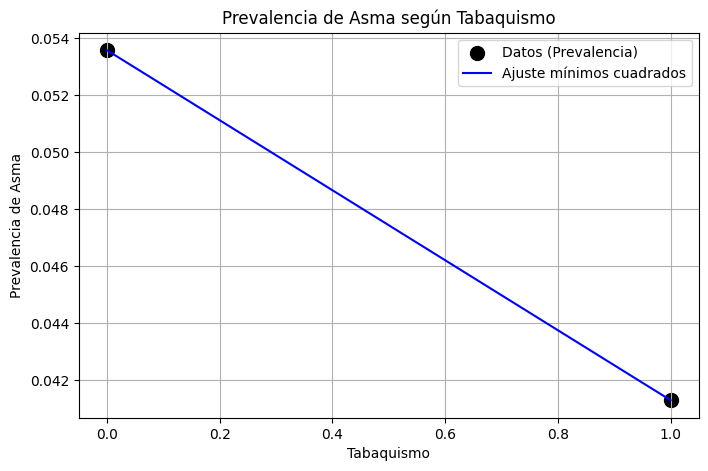

In [18]:
print('Variable: Tabaquismo')
if 'Smoking' in df.columns:
    print('\nPrevalencia por grupo/categoría:')
    prevalencia = df.groupby('Smoking')['Diagnosis'].mean()
    for label, prev in prevalencia.items():
        print(f'{label:20} {prev:.6f}')
    x = list(prevalencia.index)
    y = list(prevalencia.values)
    print('\nAjuste mínimos cuadrados:')
    resultado = minimos_cuadrados(x, y, 6)
    print(', '.join(f'{float(r):.6f}' for r in resultado))
    if len(resultado) >= 2:
        print(f'Ajuste: y = {resultado[0]:.6f} * x + {resultado[1]:.6f}')
    # Graficar ajuste
    import matplotlib.pyplot as plt
    plt.figure(figsize=(8,5))
    plt.scatter(x, y, color='black', s=100, label='Datos (Prevalencia)')
    y_fit = [resultado[0]*xi + resultado[1] for xi in x]
    plt.plot(x, y_fit, color='blue', label='Ajuste mínimos cuadrados')
    plt.title('Prevalencia de Asma según Tabaquismo')
    plt.xlabel('Tabaquismo')
    plt.ylabel('Prevalencia de Asma')
    plt.legend()
    plt.grid(True)
    plt.show()

Variable: Actividad Física

Prevalencia por grupo/categoría:
Muy Bajo o menos     0.058480
Bajo                 0.026316
Medio Bajo           0.067449
Medio                0.055556
Medio Alto           0.046921
Alto                 0.049708
Muy Alto o más       0.058480

Ajuste mínimos cuadrados:
0.000671, 0.048453
Ajuste: y = 0.000671 * x + 0.048453


/tmp/ipykernel_3933/3562723096.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  prevalencia = df.groupby('PhysicalActivityGroup')['Diagnosis'].mean()


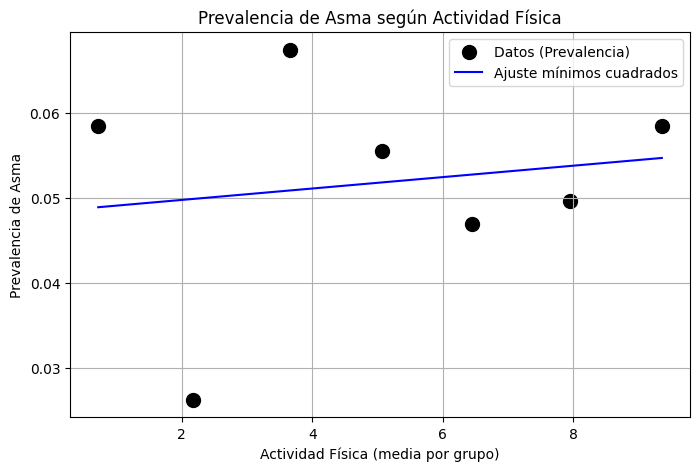

In [19]:
print('Variable: Actividad Física')
if 'PhysicalActivityGroup' in df.columns:
    print('\nPrevalencia por grupo/categoría:')
    prevalencia = df.groupby('PhysicalActivityGroup')['Diagnosis'].mean()
    for label, prev in prevalencia.items():
        print(f'{label:20} {prev:.6f}')
    x_medios = [df.loc[df['PhysicalActivityGroup'] == label, 'PhysicalActivity'].mean() for label in df['PhysicalActivityGroup'].cat.categories]
    y_prevalencia = [prevalencia[label] for label in df['PhysicalActivityGroup'].cat.categories]
    print('\nAjuste mínimos cuadrados:')
    resultado = minimos_cuadrados(x_medios, y_prevalencia, 6)
    print(', '.join(f'{float(r):.6f}' for r in resultado))
    if len(resultado) >= 2:
        print(f'Ajuste: y = {resultado[0]:.6f} * x + {resultado[1]:.6f}')
    # Graficar ajuste
    import matplotlib.pyplot as plt
    plt.figure(figsize=(8,5))
    plt.scatter(x_medios, y_prevalencia, color='black', s=100, label='Datos (Prevalencia)')
    y_fit = [resultado[0]*xi + resultado[1] for xi in x_medios]
    plt.plot(x_medios, y_fit, color='blue', label='Ajuste mínimos cuadrados')
    plt.title('Prevalencia de Asma según Actividad Física')
    plt.xlabel('Actividad Física (media por grupo)')
    plt.ylabel('Prevalencia de Asma')
    plt.legend()
    plt.grid(True)
    plt.show()

Variable: Calidad de Dieta

Prevalencia por grupo/categoría:
Muy Bajo o menos     0.052632
Bajo                 0.049708
Medio Bajo           0.043988
Medio                0.055556
Medio Alto           0.058651
Alto                 0.052632
Muy Alto o más       0.049708

Spline cúbico global sobre los valores medios de cada grupo:
Splines cúbicos naturales:
S_0(x) = -0.000657*x**3 + 0.00135372036216181*x**2 - 0.00175576094314129*x + 0.0534121717196195
S_1(x) = 0.002174*x**3 - 0.0163052158734663*x**2 + 0.0349629380067983*x + 0.0279618141722665
S_2(x) = -0.002523*x**3 + 0.0347184276708587*x**2 - 0.149771926137753*x + 0.250881347202671
S_3(x) = 0.000263*x**3 - 0.00809129667102459*x**2 + 0.0694383166267852*x - 0.123173828488345
S_4(x) = 0.001103*x**3 - 0.0243524307894587*x**2 + 0.174399720868956*x - 0.349074011505161
S_5(x) = -0.000442*x**3 + 0.0123144164561387*x**2 - 0.115649850418718*x + 0.41568668697129


/tmp/ipykernel_3933/3221312674.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  prevalencia = df.groupby('DietQualityGroup')['Diagnosis'].mean()


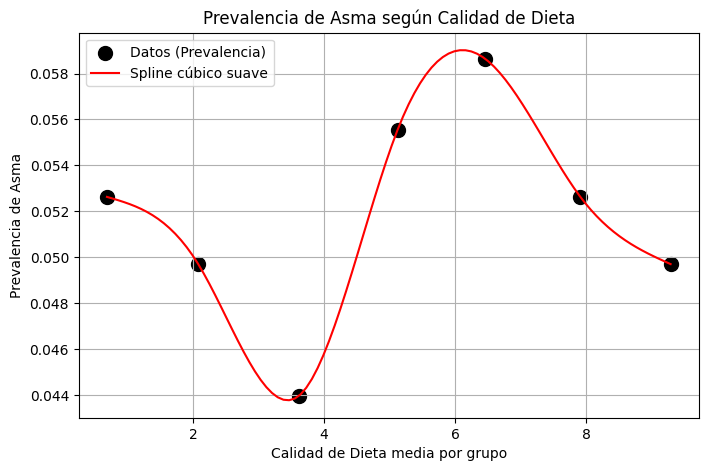

In [20]:
print('Variable: Calidad de Dieta')
if 'DietQualityGroup' in df.columns:
    print('\nPrevalencia por grupo/categoría:')
    prevalencia = df.groupby('DietQualityGroup')['Diagnosis'].mean()
    for label, prev in prevalencia.items():
        print(f'{label:20} {prev:.6f}')
    x_medios = [df.loc[df['DietQualityGroup'] == label, 'DietQuality'].mean() for label in df['DietQualityGroup'].cat.categories]
    y_prevalencia = [prevalencia[label] for label in df['DietQualityGroup'].cat.categories]
    x_filtrado = []
    y_filtrado = []
    for x, y in zip(x_medios, y_prevalencia):
        if not (pd.isna(x) or pd.isna(y)):
            x_filtrado.append(x)
            y_filtrado.append(y)
    print('\nSpline cúbico global sobre los valores medios de cada grupo:')
    if len(x_filtrado) > 1:
        spline = spline_cubico_natural_vid(x_filtrado, y_filtrado, 6)
        if spline and 'evaluar' in spline:
            x_spline = np.linspace(min(x_filtrado), max(x_filtrado), 100)
            y_spline = spline['evaluar'](x_spline)
            import matplotlib.pyplot as plt
            plt.figure(figsize=(8,5))
            plt.scatter(x_filtrado, y_filtrado, color='black', s=100, label='Datos (Prevalencia)')
            plt.plot(x_spline, y_spline, color='red', label='Spline cúbico suave')
            plt.title('Prevalencia de Asma según Calidad de Dieta')
            plt.xlabel('Calidad de Dieta media por grupo')
            plt.ylabel('Prevalencia de Asma')
            plt.legend()
            plt.grid(True)
            plt.show()
        else:
            print('No se pudo calcular el spline.')
    else:
        print('No hay suficientes datos válidos para graficar el spline.')

Variable: Historia de Alergias

Prevalencia por grupo/categoría:
                   0 0.052192
                   1 0.051309

Ajuste mínimos cuadrados:
-0.000883, 0.052192
Ajuste: y = -0.000883 * x + 0.052192


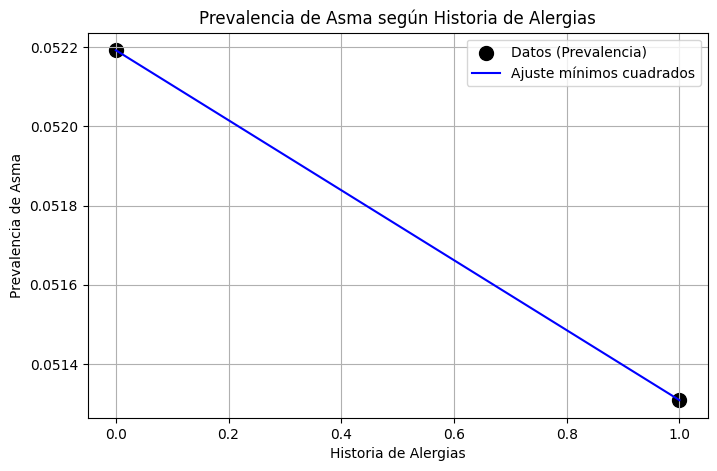

In [21]:
print('Variable: Historia de Alergias')
if 'HistoryOfAllergies' in df.columns:
    print('\nPrevalencia por grupo/categoría:')
    prevalencia = df.groupby('HistoryOfAllergies')['Diagnosis'].mean()
    for label, prev in prevalencia.items():
        print(f'{label:20} {prev:.6f}')
    x = list(prevalencia.index)
    y = list(prevalencia.values)
    print('\nAjuste mínimos cuadrados:')
    resultado = minimos_cuadrados(x, y, 6)
    print(', '.join(f'{float(r):.6f}' for r in resultado))
    if len(resultado) >= 2:
        print(f'Ajuste: y = {resultado[0]:.6f} * x + {resultado[1]:.6f}')
    # Graficar ajuste
    import matplotlib.pyplot as plt
    plt.figure(figsize=(8,5))
    plt.scatter(x, y, color='black', s=100, label='Datos (Prevalencia)')
    y_fit = [resultado[0]*xi + resultado[1] for xi in x]
    plt.plot(x, y_fit, color='blue', label='Ajuste mínimos cuadrados')
    plt.title('Prevalencia de Asma según Historia de Alergias')
    plt.xlabel('Historia de Alergias')
    plt.ylabel('Prevalencia de Asma')
    plt.legend()
    plt.grid(True)
    plt.show()

## MODELO PREDICTIVO WITH IMBLEARN AND SKLEARN

In [22]:
# Balanceo de clases con SMOTE y entrenamiento del modelo con variables agrupadas
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score

# Selección de variables agrupadas
grouped_features = [
    'AgeGroup', 'PollutionExposureGroup', 'PollenExposureGroup', 'DustExposureGroup',
    'PhysicalActivityGroup', 'DietQualityGroup',
    'Gender', 'FamilyHistoryAsthma', 'Smoking', 'HistoryOfAllergies'
]

missing = [f for f in grouped_features if f not in df.columns]
if missing:
    print('Faltan las siguientes variables agrupadas en el dataframe:', missing)
else:
    X_grouped = df[grouped_features]
    y_grouped = df['Diagnosis']

    categorical = [f for f in grouped_features if df[f].dtype.name == 'category' or df[f].dtype == object]

    preprocessor = ColumnTransformer([
        ('cat', OneHotEncoder(drop='first'), categorical)
    ], remainder='passthrough')

    # Preprocesa los datos antes de SMOTE
    X_encoded = preprocessor.fit_transform(X_grouped)

    # Aplica SMOTE para balancear las clases
    smote = SMOTE(random_state=42)
    X_resampled, y_resampled = smote.fit_resample(X_encoded, y_grouped)

    # División de datos balanceados
    X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X_resampled, y_resampled, test_size=0.3, random_state=42)

    # Entrenamiento del modelo
    model_s = LogisticRegression(max_iter=1000, class_weight='balanced')
    model_s.fit(X_train_s, y_train_s)

    # Predicciones y métricas
    y_pred_s = model_s.predict(X_test_s)
    metrics_s = {
        'accuracy': accuracy_score(y_test_s, y_pred_s),
        'recall': recall_score(y_test_s, y_pred_s, zero_division=0),
        'precision': precision_score(y_test_s, y_pred_s, zero_division=0),
        'f1': f1_score(y_test_s, y_pred_s, zero_division=0),
    }
    print('Métricas del modelo balanceado con SMOTE:')
    for k, v in metrics_s.items():
        print(f'{k}: {v*100:.6f}%')

    # Importancia de cada variable agrupada (coeficiente)
    import numpy as np
    feature_names = preprocessor.get_feature_names_out()
    coef_s = model_s.coef_[0]
    importancia_s = pd.Series(coef_s, index=feature_names).sort_values(ascending=False)
    print('\nImportancia de cada variable agrupada (coeficiente, modelo balanceado):')
    print(importancia_s)

Métricas del modelo balanceado con SMOTE:
accuracy: 61.939750%
recall: 66.717325%
precision: 59.485095%
f1: 62.893983%

Importancia de cada variable agrupada (coeficiente, modelo balanceado):
cat__DustExposureGroup_Muy Bajo o menos         0.356898
cat__PollutionExposureGroup_Bajo                0.250918
cat__DustExposureGroup_Medio                    0.229041
cat__PhysicalActivityGroup_Muy Bajo o menos     0.145512
cat__AgeGroup_<20                               0.113407
cat__PhysicalActivityGroup_Medio                0.111987
cat__PhysicalActivityGroup_Muy Alto o más       0.094173
cat__DustExposureGroup_Medio Alto               0.093749
cat__PollenExposureGroup_Bajo                   0.077268
cat__AgeGroup_60‑80                             0.062802
cat__PhysicalActivityGroup_Medio Bajo           0.023137
cat__DustExposureGroup_Bajo                    -0.033920
cat__PollutionExposureGroup_Muy Bajo o menos   -0.038762
cat__PollenExposureGroup_Muy Alto o más        -0.069708
cat__Pollu